In [10]:
import pandas as pd
df=pd.read_csv("Loan.csv")
print(df.head())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [12]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [13]:
df.rename(columns={
    "Married" :"Marital_Status"
})

,Loan_ID,Gender,Marital_Status,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [14]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
609    False
610    False
611    False
612    False
613    False
Length: 614, dtype: bool

In [15]:
df['Gender'] = df['Gender'].fillna("Male")

In [16]:
df['Married'] = df['Married'].fillna("Yes")

In [17]:
df['Dependents'] = df['Dependents'].fillna(0)

In [18]:
df['Self_Employed'] = df['Self_Employed'].fillna("Yes")

In [19]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())

In [20]:
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean())

In [21]:

df['Credit_History'] = df['Credit_History'].fillna(1.0)

In [23]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

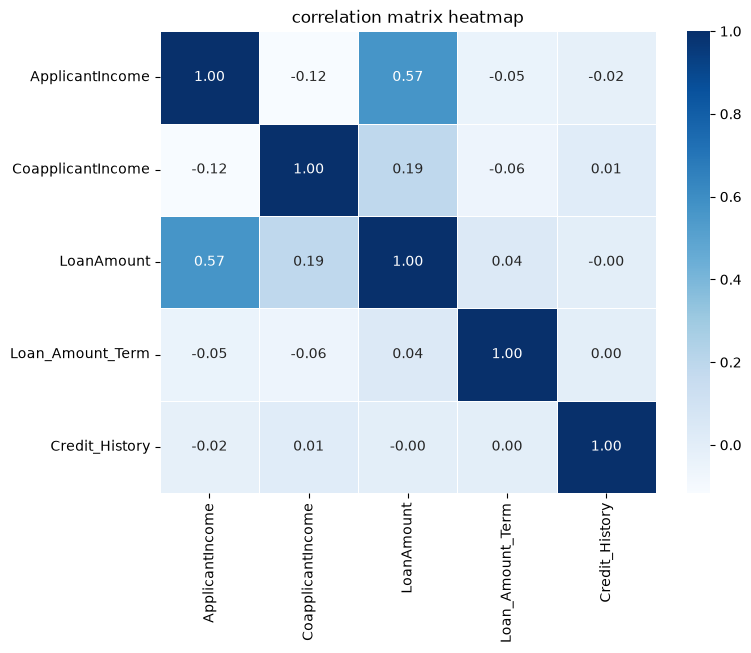

In [24]:
import  matplotlib.pyplot as plt
import seaborn as sns
corr_matrix=df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5
)
plt.title("correlation matrix heatmap")
plt.show()


In [25]:
q1=df['ApplicantIncome'].quantile(0.25)
q3=df["ApplicantIncome"].quantile(0.75)
IQR=q3-q1
lower_limit=q1-1.5*IQR
upper_limit=q3+1.5*IQR
print("q1:",q1)
print('q3:',q3)
print("IQR:",IQR)
print("lower_limit:",lower_limit)
print("upper_limit:",upper_limit)
outliers=df[
    (df["ApplicantIncome"]<lower_limit) |
    (df["ApplicantIncome"]>upper_limit)
]
print("\n ApplicantIncome Outliers:",len(outliers))
print("\n ApplicantIncome outliers:")
print(outliers[["Loan_ID","ApplicantIncome"]].head(20))

q1: 2877.5
q3: 5795.0
IQR: 2917.5
lower_limit: -1498.75
upper_limit: 10171.25

 ApplicantIncome Outliers: 50

 ApplicantIncome outliers:
      Loan_ID  ApplicantIncome
9    LP001020            12841
34   LP001100            12500
54   LP001186            11500
67   LP001233            10750
102  LP001350            13650
106  LP001369            11417
115  LP001401            14583
119  LP001422            10408
126  LP001448            23803
128  LP001451            10513
130  LP001469            20166
138  LP001492            14999
144  LP001508            11757
146  LP001516            14866
155  LP001536            39999
171  LP001585            51763
183  LP001637            33846
185  LP001640            39147
191  LP001656            12000
199  LP001673            11000


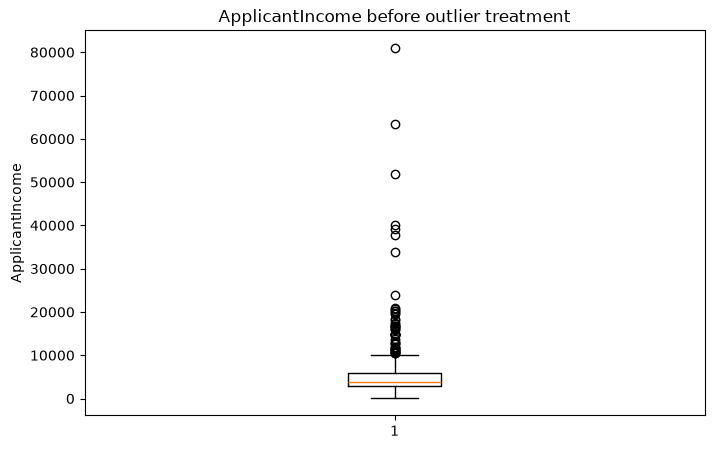

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.boxplot(df['ApplicantIncome'])
plt.title("ApplicantIncome before outlier treatment")
plt.ylabel("ApplicantIncome")
plt.show()

In [27]:
df["ApplicantIncome_capped"]=df["ApplicantIncome"].clip(
    lower=lower_limit,
    upper=upper_limit
)

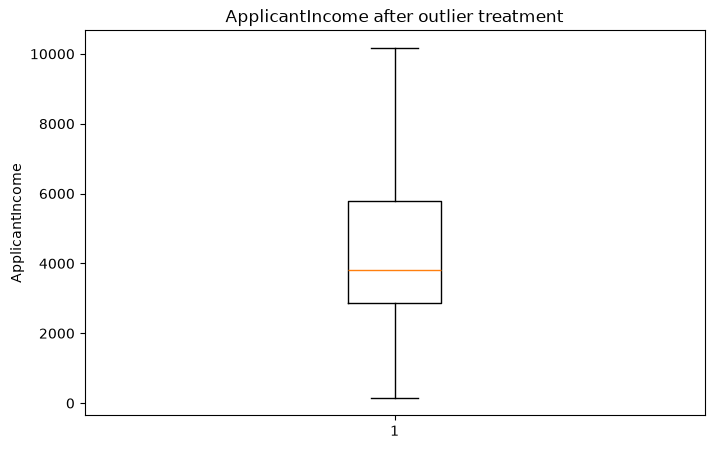

In [28]:
plt.figure(figsize=(8,5))
plt.boxplot(df['ApplicantIncome_capped'])
plt.title("ApplicantIncome after outlier treatment")
plt.ylabel("ApplicantIncome")
plt.show()

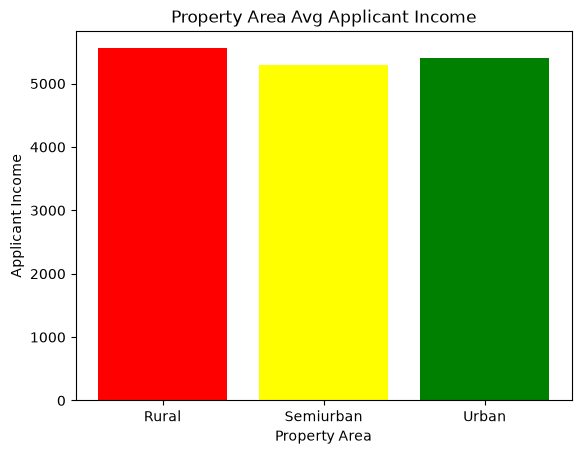

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
gender=df.groupby("Property_Area")["ApplicantIncome"].mean()
plt.bar(gender.index,
        gender.values,
        color=["red","yellow","green"]
        )
plt.title("Property Area Avg Applicant Income")
plt.xlabel("Property Area")
plt.ylabel("Applicant Income")
plt.show()


Average LoanAmount by Loan_Amount_Term:
Loan_Amount_Term
12.0     111.000000
36.0     117.500000
60.0     140.000000
84.0     132.250000
120.0     22.333333
180.0    147.473280
240.0    125.353041
300.0    185.153846
342.0    116.214286
360.0    147.214514
480.0    151.800000
Name: LoanAmount, dtype: float64


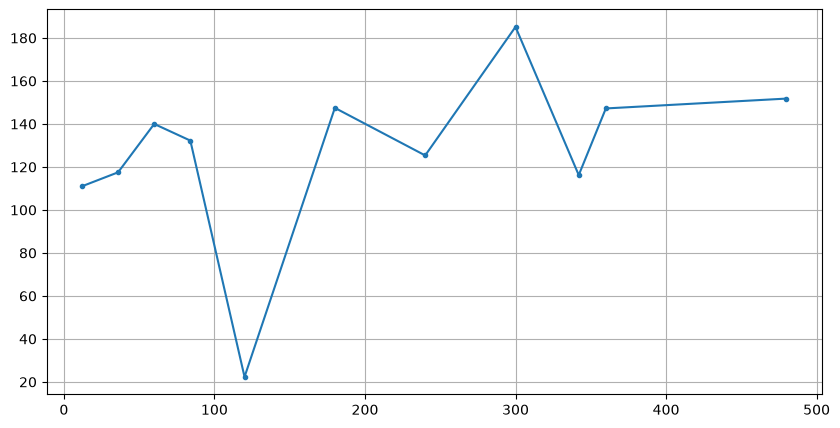

In [30]:
Loan_Amount_Term_vs_LoanAmount = df.groupby("Loan_Amount_Term")["LoanAmount"].mean()
print("\nAverage LoanAmount by Loan_Amount_Term:")
print(Loan_Amount_Term_vs_LoanAmount)
plt.figure(figsize=(10,5))
plt.plot(
    Loan_Amount_Term_vs_LoanAmount.index,
    Loan_Amount_Term_vs_LoanAmount.values,
    marker="."
)

plt.title = ("Average LoanAmount by Loan_Amount_Term ")
plt.xlabel = ("Loan_Amount_Term")
plt.ylabel = ("LoanAmount")
plt.grid(True)
plt.show()

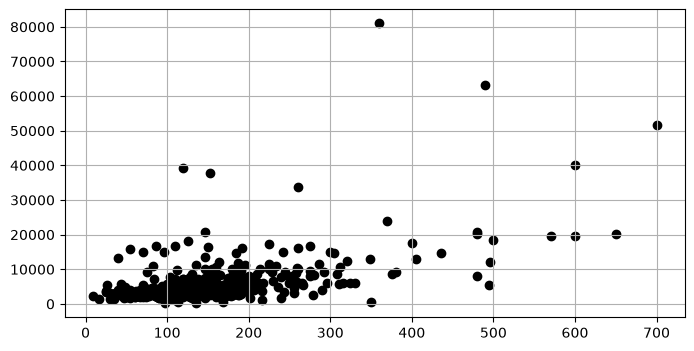

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.scatter(df["LoanAmount"], df["ApplicantIncome"], color="black")

plt.title = ("LoanAmount vs ApplicantIncome")
plt.xlabel = ("LoanAmount")
plt.ylabel = ("ApplicantIncome")
plt.grid(True)

plt.show()

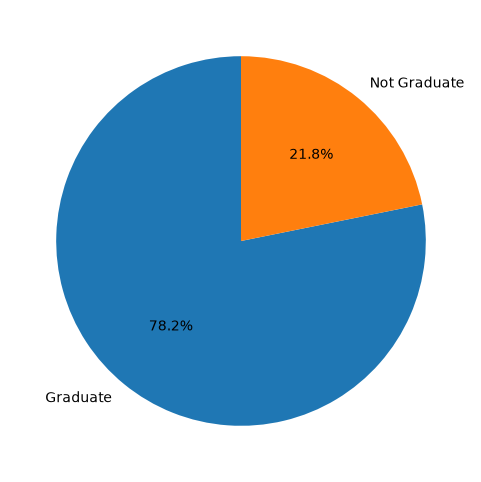

In [32]:
edu = df["Education"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(edu,
        labels=edu.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title = ("Education Distribution")
plt.show()

First 5 Rows:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0  146.412162             360.0   
1             4583             1508.0  128.000000             360.0   
2             3000                0.0   66.000000             360.0   
3             2583             2358.0  120.000000             360.0   
4             6000                0.0  141.000000             360.0   

   Credit_History Property_Area Loan_Status  ApplicantIncome_capped  
0             1.0         Urban           Y                  5849.0  
1   

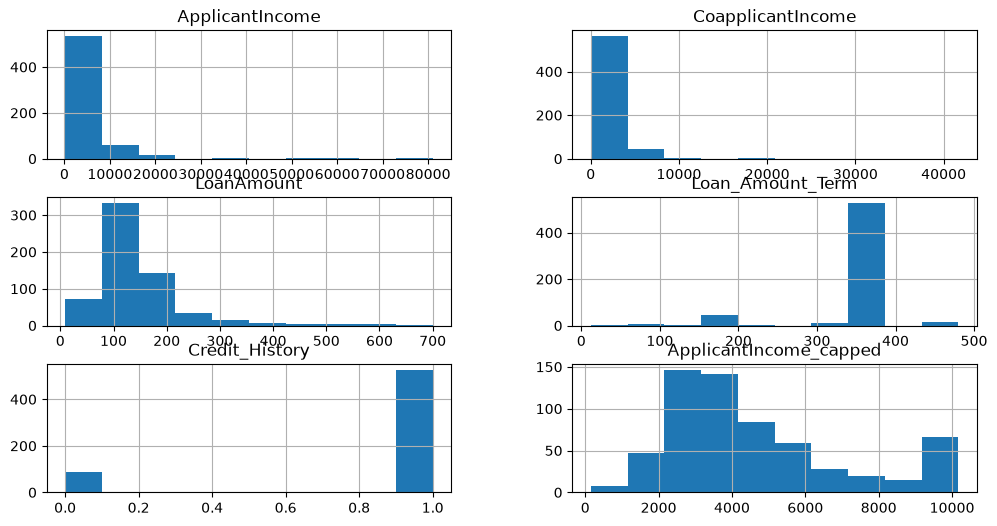

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("First 5 Rows:")
print(df.head())
print("\nLast 5 Rows:")
print(df.tail())
print("\nDataset Information:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())
print("\nShape of Dataset:")
print(df.shape)
df.hist(figsize=(12,6))
plt.title = ("Feature Distributions")
plt.show()